In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score


years = np.array(list(range(1959, 2025)))

co2_ppm = np.array([
    315.97, 316.91, 317.64, 318.45, 318.99, 319.62, 320.04, 321.38, 322.16, 323.04,
    324.62, 325.68, 326.32, 327.45, 329.68, 330.18, 331.08, 332.05, 333.78, 335.41,
    336.78, 338.68, 339.93, 341.13, 342.78, 344.42, 345.90, 347.16, 348.93, 351.48,
    352.91, 354.19, 355.62, 356.45, 357.10, 358.83, 360.82, 362.61, 363.73, 366.70,
    368.38, 369.55, 371.14, 373.28, 375.80, 377.52, 379.80, 381.90, 383.79, 385.60,
    387.43, 389.90, 391.65, 393.85, 396.52, 398.65, 400.83, 404.24, 406.55, 408.52,
    411.44, 414.24, 416.45, 418.56, 421.08, 424.61
])

df = pd.DataFrame({'year': years, 'co2_ppm': co2_ppm})
df.head()

,year,co2_ppm
0,1959,315.97
1,1960,316.91
2,1961,317.64
3,1962,318.45
4,1963,318.99


In [10]:
print('Shape:', df.shape)
print()
print(df.describe().round(2))

Shape: (66, 2)

          year  co2_ppm
count    66.00    66.00
mean   1991.50   360.12
std      19.20    32.08
min    1959.00   315.97
25%    1975.25   331.32
50%    1991.50   356.04
75%    2007.75   385.15
max    2024.00   424.61


## Exploratory Data Analysis

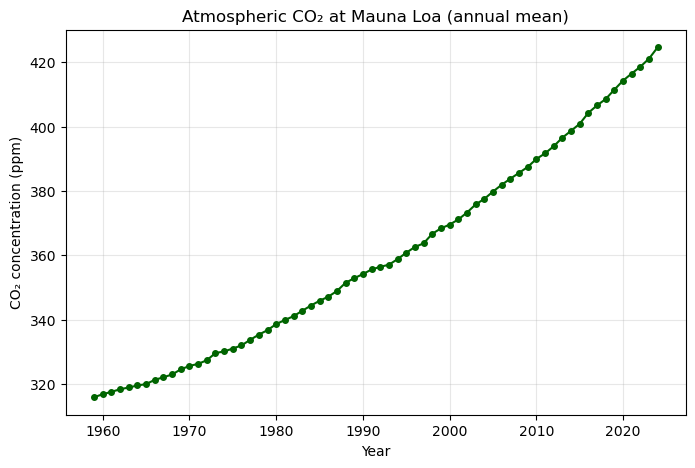

The curve bends upward over time -> a straight line would be a poor fit.


In [11]:
plt.figure(figsize=(8, 5))
plt.plot(df['year'], df['co2_ppm'], 'o-', color='darkgreen', markersize=4)
plt.xlabel('Year')
plt.ylabel('CO₂ concentration (ppm)')
plt.title('Atmospheric CO₂ at Mauna Loa (annual mean)')
plt.grid(alpha=0.3)
plt.show()

print('The curve bends upward over time -> a straight line would be a poor fit.')

## Train / Test Split (chronological)

In [12]:
X = df[['year']].values
y = df['co2_ppm'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print('Train:', int(X_train.min()), '-', int(X_train.max()))
print('Test :', int(X_test.min()), '-', int(X_test.max()))

Train: 1959 - 2010
Test : 2011 - 2024


## Try Polynomials of Different Degrees (1 to 4)

In [13]:
results = {}
for degree in range(1, 5):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[degree] = {
        'model': model,
        'r2': r2_score(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred)),
    }

print('Degree |  R^2      |  RMSE (ppm)')
print('-' * 35)
for degree, r in results.items():
    print(f'  {degree}    |  {r["r2"]:.4f}  |  {r["rmse"]:.3f}')

Degree |  R^2      |  RMSE (ppm)
-----------------------------------
  1    |  -0.6179  |  12.872
  2    |  0.9660  |  1.867
  3    |  0.8704  |  3.643
  4    |  0.8701  |  3.647


Degree 1 (plain linear) fails badly on the test period — it cannot capture the accelerating
trend. **Degree 2 (quadratic) is the best** (highest R², lowest RMSE). Degrees 3 and 4 start to
**overfit** the training years, so their test score drops. This is the classic bias–variance trade-off.

## Visualise the Fits

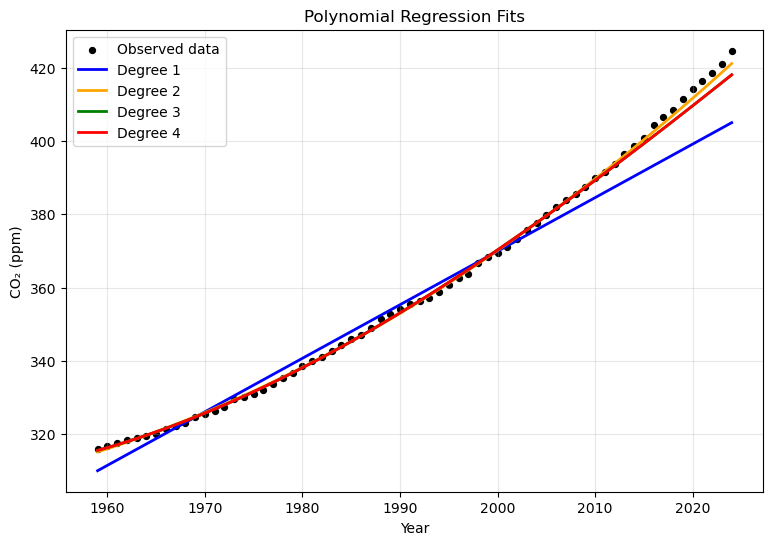

In [14]:
plt.figure(figsize=(9, 6))
plt.scatter(X, y, color='black', s=18, label='Observed data')

colors = {1: 'blue', 2: 'orange', 3: 'green', 4: 'red'}
x_line = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)

for degree, r in results.items():
    y_line = r['model'].predict(x_line)
    plt.plot(x_line, y_line, color=colors[degree], lw=2, label=f'Degree {degree}')

plt.xlabel('Year')
plt.ylabel('CO₂ (ppm)')
plt.title('Polynomial Regression Fits')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Inspect the Best Model's Coefficients

In [15]:
best_degree = max(results, key=lambda d: results[d]['r2'])
best = results[best_degree]['model']

poly = best.named_steps['polynomialfeatures']
lin = best.named_steps['linearregression']

print(f'Best degree : {poly.degree}')
print(f'Intercept   : {lin.intercept_:.3f}')
print('Coefficients (lowest to highest power):')
for p, coef in enumerate(lin.coef_):
    print(f'  x^{p}: {coef:.6f}')

Best degree : 2
Intercept   : 44982.287
Coefficients (lowest to highest power):
  x^0: 0.000000
  x^1: -46.446405
  x^2: 0.012070


## Predict Future CO₂ Levels

In [16]:
future_years = np.array([[2030], [2040], [2050]])
predictions = best.predict(future_years)

for yr, p in zip(future_years.flatten(), predictions):
    print(f'Predicted CO₂ in {yr}: {p:.1f} ppm')

Predicted CO₂ in 2030: 436.0 ppm
Predicted CO₂ in 2040: 462.8 ppm
Predicted CO₂ in 2050: 492.0 ppm
